In [1]:
import xarray
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms.functional as F
from GeoSSL.geossl.datasets import EuroSATRGB, get_dataset_spec
import torchvision.transforms as T
from torch.utils.data import Dataset

In [2]:
def plot_tile_image(tile_raster):
    red = tile_raster["red"].squeeze()
    green = tile_raster["green"].squeeze()
    blue = tile_raster["blue"].squeeze()

    rgb = np.dstack((red, green, blue))

    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

    plt.figure(figsize=(3,3))
    plt.imshow(rgb)
    plt.axis('off')
    plt.show()

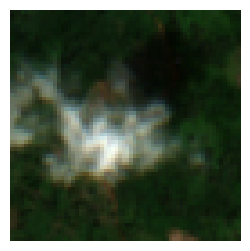

In [3]:
ar = xarray.load_dataset("data/ghana-grid-tiles/tile_5.ncf")
plot_tile_image(ar)

In [4]:
from scripts.gh_tile_dataset import GhanaTileDataset


dataset = GhanaTileDataset("data/ghana-grid-tiles")
print(len(dataset))
print(dataset[0].shape)


OSError: [Errno -51] NetCDF: Unknown file format: '/home/eli/Documents/ML/remote-sensing-ssl/data/ghana-grid-tiles/tile_178705.ncf'

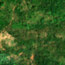

In [ ]:
F.to_pil_image(dataset[389])

In [ ]:
dataset_id = "eurosat_rgb"

dataset_spec = get_dataset_spec(dataset_id)
normalize = T.Normalize(mean=dataset_spec.mean, std=dataset_spec.std)

transform = T.Compose(
        [
            T.Resize(dataset_spec.size),
            T.CenterCrop(dataset_spec.crop_size),
            *([T.ToTensor()] if dataset_id == "eurosat_rgb" else []),
            normalize,
        ]
    )

dataset = EuroSATRGB(transform=transform, root="data/eurosat", split="val")

In [ ]:
dataset[0]

TypeError: pic should be PIL Image or ndarray. Got <class 'torch.Tensor'>

In [ ]:
import os
os.path.basename(dataset.eurosat.imgs[0][0])

'AnnualCrop_1008.tif'

In [5]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [6]:
## loading eurosat_rgb features
eurosat_rgb_simclr = pd.read_csv("data/features/eurosat_rgb-simclr-.csv")

In [7]:
features = eurosat_rgb_simclr.drop(columns=["image_name", "label"])

In [8]:
pca = PCA(n_components=2)
features_decomposed = pca.fit_transform(features)

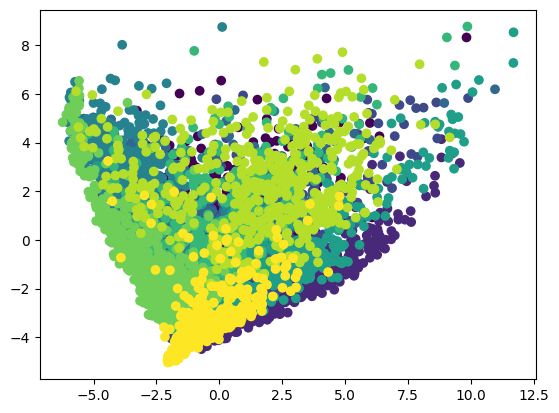

In [9]:
plt.scatter(features_decomposed[:, 0], features_decomposed[:, 1], c=eurosat_rgb_simclr["label"])

In [10]:
def pca_decompose(features, n_components=2):
    pca = PCA(n_components=n_components)
    features_decomposed = pca.fit_transform(features)
    print("Explained Variance: ", sum(pca.explained_variance_ratio_))
    return features_decomposed

In [11]:
# def plot_pca(df):
#     features = df[["feature"]]
#     features_decomposed = pca_decompose(features, n_components)
#     plt.scatter(features_decomposed[:, 0], features_decomposed[:, 1], c=eurosat_rgb_simclr["label"])
#     plt.colorbar()
#     plt.show()
#     return features_decomposed

In [ ]:
tsne = TSNE(n_components=2)

features_decomposed = tsne.fit_transform(features)

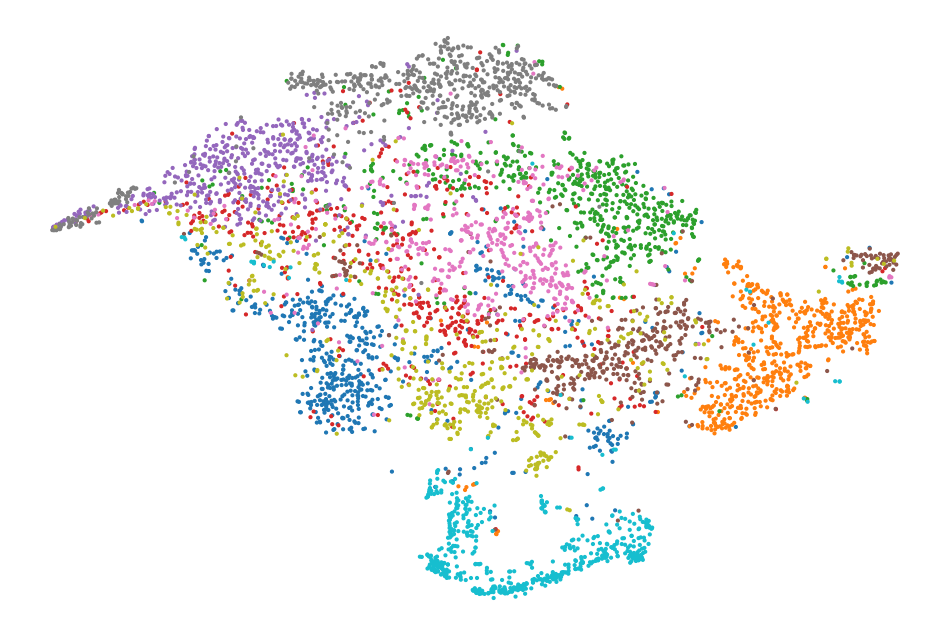

In [16]:
plt.figure(figsize=(12,8))
plt.scatter(features_decomposed[:, 0], features_decomposed[:, 1], c=eurosat_rgb_simclr["label"], s=4, cmap="tab10")
plt.axis(False)
plt.show()